# Figure 4: Multiple occluders

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-17 16:09:43,498::INFO::settings.py::Setting loglevel to INFO
2025-02-17 16:09:43,499::INFO::settings.py::Setting stores to {}
2025-02-17 16:09:43,500::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-17 16:09:43,501::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-17 16:09:43,501::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-17 16:09:43,502::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-17 16:09:43,502::INFO::settings.py::Setting database.user to celia
2025-02-17 16:09:43,503::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-17 16:09:43,646::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-17 16:09:43,755::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,238::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,238::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,637::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,637::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,797::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:44,797::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:45,164::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:45,164::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:45,555::INFO::table.py::could not log event in table ~log
2025-02-17 16:09:45,555::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
multi_occluder = [
    # Mathis lab
    {"dataset": "Nightingale_2024-08-15_1"},
    {"dataset": "Nightingale_2024-08-16_1"},
    {"dataset": "Nightingale_2024-08-21_1"},
    {"dataset": "Nightingale_2024-08-22_1"},
    {"dataset": "Lemming_2024-08-14_1"},
    {"dataset": "Lemming_2024-08-15_1"},
    {"dataset": "Lemming_2024-08-16_1"},
    {"dataset": "Lemming_2024-08-19_1"},
    {"dataset": "Jacana_2024-08-20_1"},
    {"dataset": "Jacana_2024-08-21_1"},
    {"dataset": "Jacana_2024-08-22_1"},
    {"dataset": "Kiwi_2024-08-19_1"},
    {"dataset": "Kiwi_2024-08-20_1"},
    {"dataset": "Kiwi_2024-08-21_1"},
    {"dataset": "Pheasant_2024-08-23_1"},
    {"dataset": "Pheasant_2024-08-26_1"},
    {"dataset": "Pheasant_2024-08-27_2"},
    {"dataset": "Pheasant_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-23_1"},
    {"dataset": "Oribi_2024-08-26_1"},
    {"dataset": "Oribi_2024-08-27_1"},
    {"dataset": "Oribi_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-29_1"},
    # Niell lab
    {"dataset": "J729_2024-12-11_1"},
    {"dataset": "J729_2024-12-12_1"},
    {"dataset": "J729_2024-12-13_1"},
    {"dataset": "J729_2024-12-15_1"},
]

In [6]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []

    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)

        offline_kinematics_df = dlc.OfflineKinematics().get_data(
            key=d,
            columns=["head_center_x", "head_center_y", "heading_dir", "head_angle"],
        )
        df = base_analysis.DataFrame().get_data(
            key=d,
            columns=[
                "dataset",
                "trial",
                "aperture",
                "trial_right_choice",
                "trial_left_choice",
                "velocity",
                "velocity_x",
                "velocity_y",
                "reward",
                "norm_y",
                "iti",
                "x",
                "y",
                "trial_init_x",
                "trial_init_y",
                "trial_tortuosity",
                "trial_duration",
            ],
        )
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)

        df = df.join(offline_kinematics_df)

        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage

        big_df.append(df)

    big_df = pd.concat(big_df).reset_index()
    big_df["session_increment"] = np.array(big_df.groupby("dataset").ngroup() + 1)
    big_df = big_df.infer_objects()

    return big_df.reset_index(drop=True)

In [9]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_5_occluders"') & (
    vr4mice.Collab() & "idx=3"
)
dual_list = [{"dataset": x["dataset"]} for x in dual]
if {"dataset": "J731_2024-12-15_1"} in dual_list:
    dual_list.remove({"dataset": "J731_2024-12-15_1"})
print(dual_list)
big_df = get_all_in_list(data_set_list=dual_list, training_stage="ar_discrim_occluders")

[{'dataset': 'J729_2024-12-11_1'}, {'dataset': 'J729_2024-12-12_1'}, {'dataset': 'J729_2024-12-13_1'}, {'dataset': 'J729_2024-12-15_1'}]
ar_discrim_occluders
['J729', '2024-12-11', '1']
['J729', '2024-12-12', '1']
['J729', '2024-12-13', '1']
['J729', '2024-12-15', '1']


In [ ]:
big_df = get_all_in_list(data_set_list=multi_occluder, training_stage="multi_occluder")

In [10]:
big_df.to_pickle("big_df_contrast_multi_niell.pkl")

In [5]:
niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

2025-02-17 10:23:26,764::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:23:26,764::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:23:26,770::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:23:26,770::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:23:26,812::INFO::category.py::Using categorical un

12.0:  0.2020847413725807 std:  0.03193350991598985
12.0-3.0: TtestResult(statistic=0.11790279442601181, pvalue=0.9070508208507786, df=26)
12.0-4.2: TtestResult(statistic=0.28703094776580623, pvalue=0.7763637501102679, df=26)
12.0-6.0: TtestResult(statistic=0.009386718228343175, pvalue=0.9925822474897206, df=26)
12.0-8.48: TtestResult(statistic=0.6780895928754609, pvalue=0.5037055485555197, df=26)
3.0:  0.20082474100927838 std:  0.03150965301236884
3.0-4.2: TtestResult(statistic=0.13427508592097614, pvalue=0.8942190758360513, df=26)
3.0-6.0: TtestResult(statistic=-0.14309094498041497, pvalue=0.887321555719043, df=26)
3.0-8.48: TtestResult(statistic=0.6053026988479357, pvalue=0.5502253288943371, df=26)
4.2:  0.1994059606640248 std:  0.030695902038111723
4.2-6.0: TtestResult(statistic=-0.3358271126323376, pvalue=0.7396962688820488, df=26)
4.2-8.48: TtestResult(statistic=0.37725238022337243, pvalue=0.7090479105251353, df=26)
6.0:  0.20200063925761588 std:  0.025677746181849186
6.0-8.48: T

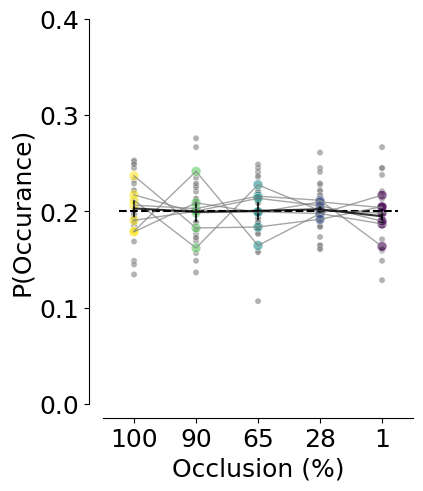

In [24]:
# Occurance of the different conditions
counts = (
    big_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    big_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(4, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_multi_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.2,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 0.4)
plt.xlim(-0.5, 4.5)
plt.xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.xlabel("Occlusion (%)")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_multi_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
for i in counts.probability.columns:
    print(
        f"{i}: ",
        np.mean(np.array(counts["probability"][i])),
        "std: ",
        np.std(np.array(counts["probability"][i])),
    )
    for j in counts.probability.columns:
        if i < j:
            stat = ttest_rel(
                np.array(counts["probability"][i]), np.array(counts["probability"][j])
            )
            print(f"{i}-{j}: {stat}")

2025-02-17 10:21:54,497::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:21:54,497::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:21:54,503::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:21:54,503::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:21:54,614::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=-4.883039824612757, pvalue=4.575810934824732e-05, df=26)
3.0-6.0: TtestResult(statistic=-8.334971731187746, pvalue=8.127478322488372e-09, df=26)
3.0-8.48: TtestResult(statistic=-9.626066365043604, pvalue=4.659831753327948e-10, df=26)
4.2-6.0: TtestResult(statistic=-4.504409750320275, pvalue=0.00012434560588118544, df=26)
4.2-8.48: TtestResult(statistic=-5.6126179638747935, pvalue=6.725918557019944e-06, df=26)
6.0-8.48: TtestResult(statistic=-1.3049969335273903, pvalue=0.20332614895703321, df=26)
12.0-3.0: TtestResult(statistic=7.129418279981534, pvalue=1.4296081360946502e-07, df=26)
12.0-4.2: TtestResult(statistic=3.231975371248211, pvalue=0.00332782634190908, df=26)
12.0-6.0: TtestResult(statistic=-0.0379510599605678, pvalue=0.9700166024832286, df=26)
12.0-8.48: TtestResult(statistic=-0.8397942588922601, pvalue=0.4086798655409576, df=26)
              mean       sem
aperture                    
12.0      0.929952  0.013453
3.0       0.747642  0.019602
4.

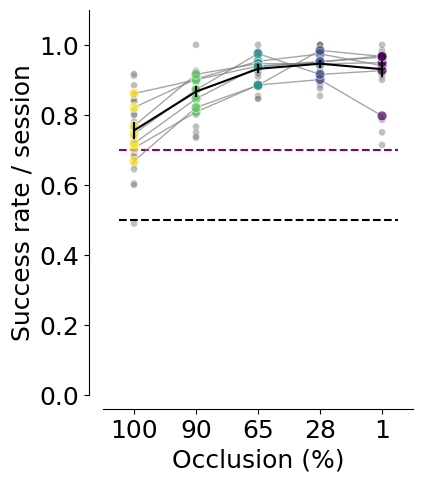

In [23]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_multi_occluder_rewards.svg", transparent=True)

In [25]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)

mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
    )
    .mean(numeric_only=True)
    .copy()
)

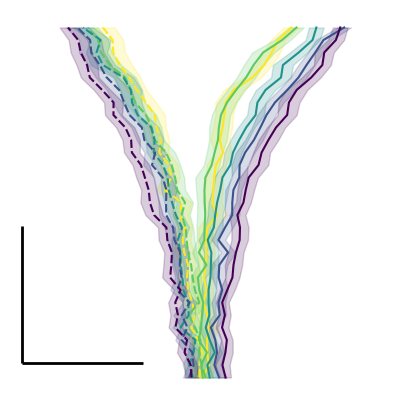

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x=mean_mouse.bin_centers,
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")
ax.legend([], [], frameon=False)
sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure4_multi_occluder_mean_trajectories.svg", transparent=True
)

In [36]:
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)
j_shaped = j_shaped
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped["x_flipped"] = j_shaped.x * j_shaped.flip_one_side
mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)
mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

In [37]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              21.1742   4.0000  104.0000 0.0000
bin_centers          245.2239  28.0000  728.0000 0.0000
aperture:bin_centers   5.7862 112.0000 2912.0000 0.0000



**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

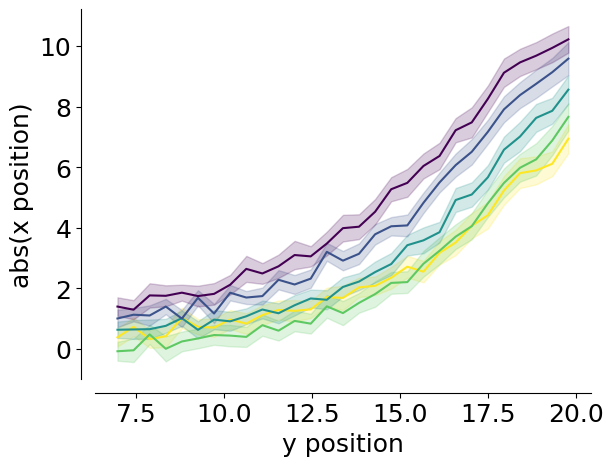

In [46]:
sns.lineplot(
    data=mean_mouse,
    x="bin_centers",
    y="x_flipped",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
    alpha=1,
)

plt.ylabel("abs(x position)")
plt.xlabel("y position")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_position_flipped.svg", transparent=True)

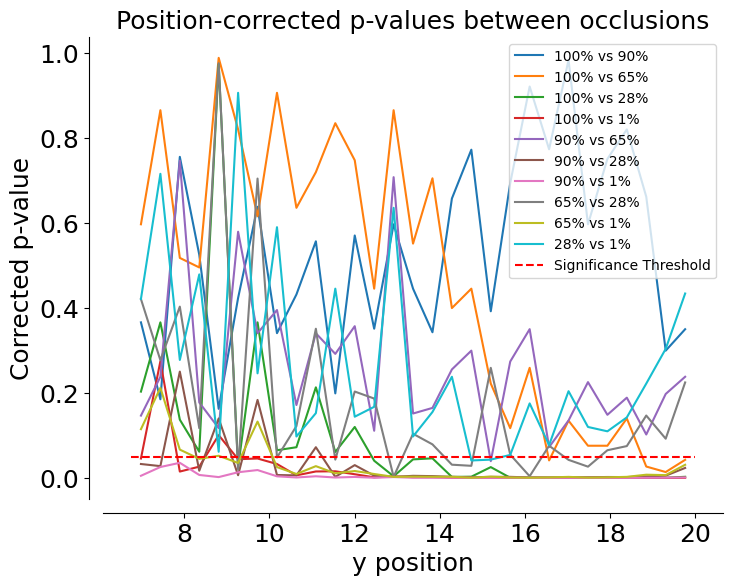

In [42]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as smm

p_values = []
apertures = mean_mouse.aperture.unique()
percentage_pairs = ["100%", "90%", "65%", "28%", "1%"]

pairwise_comparisons = list(
    itertools.combinations(apertures, 2)
)  # Generate all pairs of apertures
pairwise_percentage = list(
    itertools.combinations(percentage_pairs, 2)
)  # Generate all pairs of apertures

for i in mean_mouse.bin_centers.unique():
    section = mean_mouse[mean_mouse.bin_centers == i]

    for ap1, ap2 in pairwise_comparisons:
        t = ttest_ind(
            section[section.aperture == ap1].x_flipped,
            section[section.aperture == ap2].x_flipped,
        )

        p_values.append(
            pd.DataFrame(
                {"segment": i, "aperture_pair": f"{ap1} vs {ap2}", "p_value": t.pvalue},
                index=[0],
            )
        )

# Convert to DataFrame
p_value_df = pd.concat(p_values)

# Apply False Discovery Rate (FDR) correction across all comparisons
p_value_df["p_value_corr"] = smm.multipletests(p_value_df.p_value, method="fdr_bh")[1]

# Plot results for each aperture pair
plt.figure(figsize=(8, 6))
for pair, label_pair in zip(pairwise_comparisons, pairwise_percentage):
    subset = p_value_df[p_value_df.aperture_pair == f"{pair[0]} vs {pair[1]}"]
    plt.plot(
        subset.segment, subset.p_value_corr, label=f"{label_pair[0]} vs {label_pair[1]}"
    )

plt.hlines(
    0.05,
    xmin=6.75,
    xmax=20,
    color="red",
    linestyle="dashed",
    label="Significance Threshold",
)
plt.xlabel("y position")
plt.ylabel("Corrected p-value")
plt.title("Position-corrected p-values between occlusions")
plt.legend()
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure4_position_pvalue.svg", transparent=True)
plt.show()

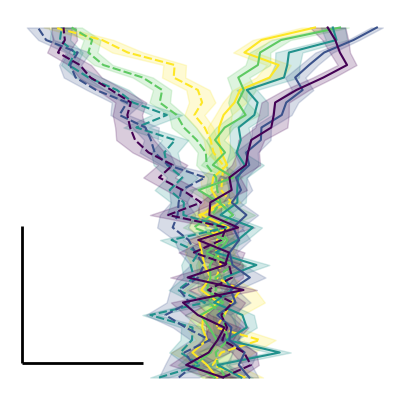

In [44]:
# Example

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=j_shaped[j_shaped.dataset == "Kiwi_2024-08-19_1"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)

ax.legend([], [], frameon=False)
plt.axis("off")
plt.savefig(
    save_fig_path + "figure4_multi_occluder_trajectories_example_session.svg",
    transparent=True,
)